# Ettin classifier (jhu-clsp/ettin-encoder-400m)

The SOTA encoder - [Ettin Suite: SoTA Paired Encoders and Decoders](https://huggingface.co/blog/ettin)

### Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import json

from google.colab import drive, userdata

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch
from datasets import Dataset

### Set up Google Drive mounting and define input/output paths:

In [ ]:
# Mount the google drive folder
drive.mount('/content/drive', force_remount = True) # force reconnection

# Define directory, input, and output paths
project_directory = "/content/drive/MyDrive/Colab Notebooks/DS266/final_project"

# Input file with all original-rewrite pairs
final_file = os.path.join(project_directory, "data/final_long_no_leak.parquet")

# # Output file
# output_file = os.path.join(project_directory, "data/out.parquet")

# Ensure the output directory exists
if not os.path.exists(project_directory):
  os.makedirs(project_directory)

Mounted at /content/drive


### Read the input file:

In [ ]:
# Read input file with ALL sampled original-rewrite pairs
final_df = pd.read_parquet(final_file)
print('Sucessfully read the input file with ALL original-rewrite pairs!')

print(f'The input file contains {len(final_df)} records/rows.')
print(f'Column names: {list(final_df.columns)}')

print('\nThe first 3 rows:')
display(final_df.head(3))

Sucessfully read the input file with ALL original-rewrite pairs!
The input file contains 105097 records/rows.
Column names: ['question', 'original_answer', 'rewritten_answer', 'original_author', 'rewrite_author', 'split']

The first 3 rows:


,question,original_answer,rewritten_answer,original_author,rewrite_author,split
0,what composer used sound mass,The most prominent composer strongly associate...,The most prominent composer associated with th...,gemini,claude,train
1,where did the persian war take place,The Persian Wars primarily took place in **mai...,The Persian Wars primarily took place across *...,gemini,claude,train
2,what are add ons,An **add-on** is something extra or additional...,An **add-on** is an optional component that en...,gemini,claude,train


### Data Exploration & cleaning

In [ ]:
print(final_df['original_author'].value_counts(), end = '\n\n')
print(final_df['rewrite_author'].value_counts())

original_author
gpt       21160
claude    21138
human     21024
gemini    20980
kimi      20795
Name: count, dtype: int64

rewrite_author
kimi      26477
claude    26456
gemini    26297
gpt       25867
Name: count, dtype: int64


In [ ]:
print(final_df.isna().sum(), end = '\n\n')

# na_df -- the dataframe that contains nan responses (rewrites)
na_df = final_df[final_df['rewritten_answer'].isna()]

print(na_df['rewrite_author'].value_counts())
display(na_df.head(3))

question            0
original_answer     0
rewritten_answer    0
original_author     0
rewrite_author      0
split               0
dtype: int64

Series([], Name: count, dtype: int64)


,question,original_answer,rewritten_answer,original_author,rewrite_author,split


Create the numeric `labels` in a new column:
- 0 - kimi
- 1 - gpt
- 2 - claude
- 3 - gemini

In [ ]:
# Create the 'labels' column

# Define the label ids correspond to human and each LLM
author_to_id = {'kimi': 0,
                'gpt': 1,
                'claude': 2,
                'gemini': 3}                                                  # ONLY 4 CLASSES FOR REWRITERS!!!!
id_to_author = {id: author for author, id in author_to_id.items()}

# Map the rewrite author (human and LLMs) to numeric values
final_df['labels'] = final_df['rewrite_author'].map(author_to_id).astype(int) # PREDICT REWIRTERS!!!!
display(final_df.head(3))

,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,what composer used sound mass,The most prominent composer strongly associate...,The most prominent composer associated with th...,gemini,claude,train,2
1,where did the persian war take place,The Persian Wars primarily took place in **mai...,The Persian Wars primarily took place across *...,gemini,claude,train,2
2,what are add ons,An **add-on** is something extra or additional...,An **add-on** is an optional component that en...,gemini,claude,train,2


In [ ]:
# train-test split --> DO THIS FIRST BC SPLIT IS PREASSIGNED

# Combine test and val
train_df = final_df[final_df['split'] == 'train'].reset_index(drop = True)
test_df = final_df[final_df['split'].isin(['test', 'val'])].reset_index(drop = True)

print(f'Total samples: {len(final_df)}')
print(f'Training samples: {len(train_df)} | {len(train_df)/len(final_df):.2%}')
print(f'Testing samples: {len(test_df)} | {len(test_df)/len(final_df):.2%}')

Total samples: 105097
Training samples: 73586 | 70.02%
Testing samples: 31511 | 29.98%


In [ ]:
# stratification (train)

print(f'Total training data size before stratification: {len(train_df)}\n')
print(train_df['rewrite_author'].value_counts(), end = '\n\n')

df_gemini = train_df[train_df['rewrite_author'] == 'gemini']
df_gpt = train_df[train_df['rewrite_author'] == 'gpt']
df_claude = train_df[train_df['rewrite_author'] == 'claude']
df_kimi = train_df[train_df['rewrite_author'] == 'kimi']

# Get the smallest value counts from the column 'rewrite_author'
min_rewrite_author_count = min(train_df['rewrite_author'].value_counts())

# Sample with this min so that each class has the same count
df_gemini_sampled = df_gemini.sample(n = min_rewrite_author_count, random_state = 42)
df_gpt_sampled = df_gpt.sample(n = min_rewrite_author_count, random_state = 42)
df_claude_sampled = df_claude.sample(n = min_rewrite_author_count, random_state = 42)
df_kimi_sampled = df_kimi.sample(n = min_rewrite_author_count, random_state = 42)

# Concat all the dataframes
train_df = pd.concat([df_gemini_sampled, df_gpt_sampled, df_claude_sampled, df_kimi_sampled]).reset_index(drop = True)
print(f'Total training data size after stratification: {len(train_df)}\n')
print(train_df['rewrite_author'].value_counts(), end = '\n\n')
print(train_df['labels'].value_counts(), end = '\n\n')
display(train_df.head(3))

Total training data size before stratification: 73586

rewrite_author
kimi      18533
claude    18521
gemini    18414
gpt       18118
Name: count, dtype: int64

Total training data size after stratification: 72472

rewrite_author
gemini    18118
gpt       18118
claude    18118
kimi      18118
Name: count, dtype: int64

labels
3    18118
1    18118
2    18118
0    18118
Name: count, dtype: int64



,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,Suggest alternative medication in place of Hol...,Short answer\n- If you want the same active an...,**Effective Cough Relief: Beyond the Lozenge**...,gpt,gemini,train,3
1,$65000/year or $2500 every two weeks: If I cla...,# Take-Home Pay Calculation\n\nI need to clari...,# Understanding Your Take-Home Pay\n\nIt appea...,claude,gemini,train,3
2,who produced loyal to the game?,"""Loyal to the Game"" (the posthumous 2Pac album...",Eminem was the primary producer and executive ...,gpt,gemini,train,3


In [ ]:
# stratification (test)

print(f'Total testing data size before stratification: {len(test_df)}\n')
print(test_df['rewrite_author'].value_counts(), end = '\n\n')

df_gemini = test_df[test_df['rewrite_author'] == 'gemini']
df_gpt = test_df[test_df['rewrite_author'] == 'gpt']
df_claude = test_df[test_df['rewrite_author'] == 'claude']
df_kimi = test_df[test_df['rewrite_author'] == 'kimi']

# Get the smallest value counts from the column 'rewrite_author'
min_rewrite_author_count = min(test_df['rewrite_author'].value_counts())

df_gemini_sampled = df_gemini.sample(n = min_rewrite_author_count, random_state = 42)
df_gpt_sampled = df_gpt.sample(n = min_rewrite_author_count, random_state = 42)
df_claude_sampled = df_claude.sample(n = min_rewrite_author_count, random_state = 42)
df_kimi_sampled = df_kimi.sample(n = min_rewrite_author_count, random_state = 42)

test_df = pd.concat([df_gemini_sampled, df_gpt_sampled, df_claude_sampled, df_kimi_sampled]).reset_index(drop = True)
print(f'Total testing data size after stratification: {len(test_df)}\n')
print(test_df['rewrite_author'].value_counts(), end = '\n\n')
print(test_df['labels'].value_counts(), end = '\n\n')
display(test_df.head(3))

Total testing data size before stratification: 31511

rewrite_author
kimi      7944
claude    7935
gemini    7883
gpt       7749
Name: count, dtype: int64

Total testing data size after stratification: 30996

rewrite_author
gemini    7749
gpt       7749
claude    7749
kimi      7749
Name: count, dtype: int64

labels
3    7749
1    7749
2    7749
0    7749
Name: count, dtype: int64



,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,Is asthalin inhaler recommended for cough of a...,It's completely understandable to be concerned...,It's completely understandable to be concerned...,gemini,gemini,test,3
1,Can limits be placed by a merchant on which cu...,Short answer: Usually yes — private merchants ...,"**Short Answer:** Generally, yes. Private merc...",gpt,gemini,test,3
2,"Q. Apart from extraction, is there any way to ...",Hello. Wisdom teeth or third molars are usuall...,"Wisdom teeth, or third molars, are typically t...",human,gemini,test,3


In [ ]:
# Shuffle the data (train & val+test individually)
shuffled_indices_train = np.random.permutation(len(train_df))
shuffled_indices_test = np.random.permutation(len(test_df))

train_df = train_df.iloc[shuffled_indices_train].reset_index(drop = True)
test_df = test_df.iloc[shuffled_indices_test].reset_index(drop = True)

print(f'Unique \'split\' values in the training dataset: {train_df["split"].unique()}')
print(f'Unique \'split\' values in the testing dataset: {test_df["split"].unique()}\n')

# Verify that the split was done correctly
display(train_df.head(2))
display(test_df.head(2))

Unique 'split' values in the training dataset: ['train']
Unique 'split' values in the testing dataset: ['test' 'val']



,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,who is the guy in the wheelchair who is smart,"That's a great question, as there are a few ve...","That's an excellent question, as several promi...",gemini,claude,train,2
1,What kinds of exchange-traded funds (ETFs) sho...,As with ANY investment the first answer is.......,"As with any investment, the primary rule is to...",human,gemini,train,3


,question,original_answer,rewritten_answer,original_author,rewrite_author,split,labels
0,Why does it take 3 days to do electronic trans...,"It's a common and very valid question, especia...","It's a common and valid question, especially i...",gemini,gemini,test,3
1,what forms seasons,Seasons are primarily caused by the tilt of a ...,Seasons are caused mainly by the tilt of a pla...,gpt,gpt,val,1


In [ ]:
# Check if there's class imbalance
print(f'Label value counts on the training dataset:\n{train_df['labels'].value_counts()}')
print(f'Label value counts on the testing dataset:\n{test_df['labels'].value_counts()}')

Label value counts on the training dataset:
labels
2    18118
3    18118
0    18118
1    18118
Name: count, dtype: int64
Label value counts on the testing dataset:
labels
3    7749
1    7749
2    7749
0    7749
Name: count, dtype: int64


In [ ]:
# Convert the training and testing dataset to Dataset format

train_data = Dataset.from_pandas(train_df[['original_answer', 'rewritten_answer', 'labels']])
test_data = Dataset.from_pandas(test_df[['original_answer', 'rewritten_answer', 'labels']])

### Ettin classifier development

Define tokenizer

In [ ]:
ettin_checkpoint = 'jhu-clsp/ettin-encoder-400m'
ettin_tokenizer = AutoTokenizer.from_pretrained(ettin_checkpoint)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Define the training and testing inputs

In [ ]:
def tokenization(df):
  return ettin_tokenizer(df['original_answer'],
                         df['rewritten_answer'], # Feeding both the original and rewritten answers bc Ettin is good for analyzing pairs
                         padding = 'max_length',
                         truncation = True,
                         max_length = 512)

train_tokenized = train_data.map(tokenization, batched = True)
train_tokenized.set_format('torch')

test_tokenized = test_data.map(tokenization, batched = True)
test_tokenized.set_format('torch')

Map:   0%|          | 0/72472 [00:00<?, ? examples/s]

Map:   0%|          | 0/30996 [00:00<?, ? examples/s]

Define metrics

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis = -1)

    return {'accuracy': accuracy_score(labels, predictions),
            'f1_score': f1_score(labels, predictions, average = 'macro')} # for multiclass, will treat each class with equal weights

### Baseline model (untrained Ettin)

In [ ]:
ettin_baseline_model = AutoModelForSequenceClassification.from_pretrained(ettin_checkpoint, num_labels = 4) # 4 classes

baseline_training_args = TrainingArguments(output_dir = './ettin_baseline',
                                           per_device_eval_batch_size = 8)

baseline_trainer = Trainer(model = ettin_baseline_model,
                           args = baseline_training_args,
                           eval_dataset = test_tokenized,
                           compute_metrics = compute_metrics)

pytorch_model.bin:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/ettin-encoder-400m
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
decoder.weight    | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
baseline_results = baseline_trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


In [ ]:
print(f"(Baseline) Accuracy: {baseline_results['eval_accuracy']} | F1: {baseline_results['eval_f1_score']}")

(Baseline) Accuracy: 0.2588075880758808 | F1: 0.19999995603744355


This makes sense for an untrained model. `0.259` is roughly `25%` - each class's proportion

### Fine-tuned model (trained)

In [ ]:
ettin_finetuned_model = AutoModelForSequenceClassification.from_pretrained(ettin_checkpoint, num_labels = 4) # 4 classes

finetune_training_args = TrainingArguments(output_dir = './ettin_finetuned',
                                           num_train_epochs = 3,                # likely converged for Ettin
                                           learning_rate = 0.00002,
                                           per_device_train_batch_size = 16,    # to prevent overfitting
                                           per_device_eval_batch_size = 16,     # to prevent overfitting
                                           eval_strategy = 'epoch',
                                           save_strategy = 'epoch',
                                           weight_decay = 0.01,                 # prevent overfitting to specific punctuation habits
                                           load_best_model_at_end = True,
                                           metric_for_best_model = 'f1_score',  # evauate overall performances across 5 classes
                                           logging_steps = 100,
                                           warmup_steps = 500,                  # stablize the gradients
                                           fp16 = True)                         # for faster training

finetune_trainer = Trainer(model = ettin_finetuned_model,
                           args = finetune_training_args,
                           train_dataset = train_tokenized,
                           eval_dataset = test_tokenized,
                           compute_metrics = compute_metrics)

finetune_trainer.train()

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/ettin-encoder-400m
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
decoder.weight    | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score
1,0.131270,0.156514,0.943799,0.943691
2,0.104814,0.145439,0.954736,0.954748
3,0.031765,0.218808,0.957478,0.957503


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=13590, training_loss=0.13370441922025703, metrics={'train_runtime': 2085.5633, 'train_samples_per_second': 104.248, 'train_steps_per_second': 6.516, 'total_flos': 2.2993096688831693e+17, 'train_loss': 0.13370441922025703, 'epoch': 3.0})

In [ ]:
finetuned_results = finetune_trainer.evaluate()

In [ ]:
print(f"(Baseline) Accuracy: {baseline_results['eval_accuracy']} | F1: {baseline_results['eval_f1_score']}")
print(f"(Finetuned) Accuracy: {finetuned_results['eval_accuracy']} | F1: {finetuned_results['eval_f1_score']}")

(Baseline) Accuracy: 0.2588075880758808 | F1: 0.19999995603744355
(Finetuned) Accuracy: 0.9574783843076526 | F1: 0.9575027740954527


### Test Evaluation and Visualization

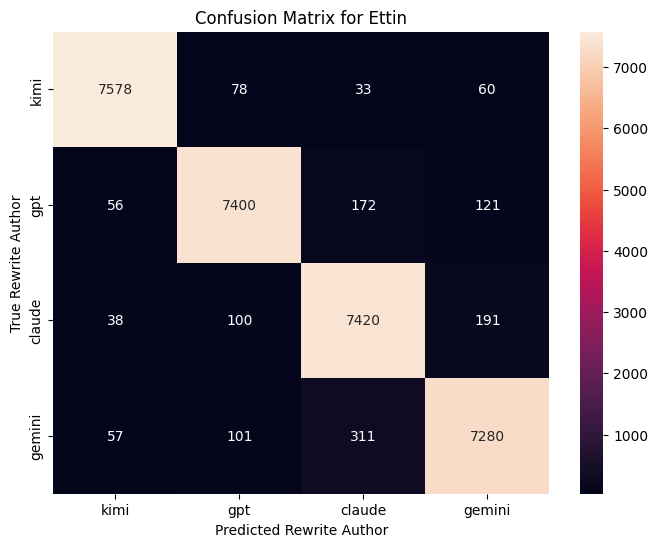


Classification Report:
              precision    recall  f1-score   support

        kimi       0.98      0.98      0.98      7749
         gpt       0.96      0.95      0.96      7749
      claude       0.93      0.96      0.95      7749
      gemini       0.95      0.94      0.95      7749

    accuracy                           0.96     30996
   macro avg       0.96      0.96      0.96     30996
weighted avg       0.96      0.96      0.96     30996



In [ ]:
predictions = finetune_trainer.predict(test_tokenized)
pred = np.argmax(predictions.predictions, axis = -1)
labels = test_df['labels'].values

cm = confusion_matrix(labels, pred)
plt.figure(figsize = (8, 6))
sns.heatmap(cm,
            annot = True,
            fmt = 'd', # format the annotation from scientific to decimals
            xticklabels = [author for id, author in id_to_author.items()],
            yticklabels = [author for id, author in id_to_author.items()])
plt.xlabel('Predicted Rewrite Author')
plt.ylabel('True Rewrite Author')
plt.title('Confusion Matrix for Ettin')
plt.show()

print("\nClassification Report:")
print(classification_report(labels, pred, target_names = [author for id, author in id_to_author.items()]))

### Edit-resistance Analysis

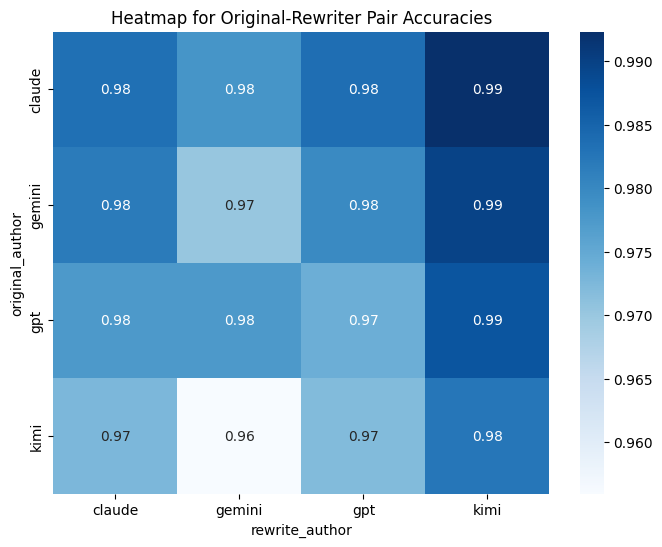

In [ ]:
test_df_copy = test_df.copy()
test_df_copy['pred'] = pred

# Compute accuracies for all original-rewrite pairs
grouped_test_df = test_df_copy[test_df_copy['original_author'] != 'human'].groupby(['original_author', 'rewrite_author']).apply(
    lambda row: (row['labels'] == row['pred']).mean(),
    include_groups = False).unstack()

plt.figure(figsize = (8, 6))
sns.heatmap(grouped_test_df,
            annot = True,
            cmap = 'Blues')
plt.title('Heatmap for Original-Rewriter Pair Accuracies')
plt.show()

### Save the final dataframe to parquet

In [ ]:
finetune_trainer.save_model("./finetuned_ettin")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]